# SQL Data Project
## Chinook Database Analysis
This project uses Python, SQLite, Pandas and Matplotlib to analyze the chinook sample database and answer business questions

## 1.Import libraries

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 2.Connect to the Database
In this section, we connect python to the Chinook SQLite database using the sqlite3 libraries

In [2]:
conn = sqlite3.connect("Chinook_Sqlite.sqlite")
print("connected successfully")

connected successfully


## 3.Explore table structure
The following queries display the column of important tables

In [4]:
# sql query to list all table
query = """
SELECT name 
From sqlite_master
Where type = 'table';
"""
tables = pd.read_sql(query, conn)

tables



,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [67]:
query = """
SELECT FirstName
FROM Employee;
"""

Employee = pd.read_sql(query, conn)
Employee

,FirstName
0,Andrew
1,Nancy
2,Jane
3,Margaret
4,Steve
5,Michael
6,Robert
7,Laura


In [36]:
query = """
SELECT Invoiceid
FROM Invoice;
"""

Invoice = pd.read_sql(query, conn)
Invoice

,InvoiceId
0,98
1,121
2,143
3,195
4,316
...,...
407,45
408,97
409,218
410,229


In [32]:
query = """
SELECT UnitPrice
FROM Track;
"""

Track = pd.read_sql(query, conn)
Track

,UnitPrice
0,0.99
1,0.99
2,0.99
3,0.99
4,0.99
...,...
3498,0.99
3499,0.99
3500,0.99
3501,0.99


In [14]:
pd.read_sql(
    "pragma table_info(Invoice);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,InvoiceId,INTEGER,1,None,1
1,1,CustomerId,INTEGER,1,None,0
2,2,InvoiceDate,DATETIME,1,None,0
3,3,BillingAddress,NVARCHAR(70),0,None,0
4,4,BillingCity,NVARCHAR(40),0,None,0
5,5,BillingState,NVARCHAR(40),0,None,0
6,6,BillingCountry,NVARCHAR(40),0,None,0
7,7,BillingPostalCode,NVARCHAR(10),0,None,0
8,8,Total,"NUMERIC(10,2)",1,None,0


In [6]:
pd.read_sql(
    "pragma table_info(Track);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,TrackId,INTEGER,1,None,1
1,1,Name,NVARCHAR(200),1,None,0
2,2,AlbumId,INTEGER,0,None,0
3,3,MediaTypeId,INTEGER,1,None,0
4,4,GenreId,INTEGER,0,None,0
5,5,Composer,NVARCHAR(220),0,None,0
6,6,Milliseconds,INTEGER,1,None,0
7,7,Bytes,INTEGER,0,None,0
8,8,UnitPrice,"NUMERIC(10,2)",1,None,0


In [12]:
pd.read_sql(
    "pragma table_info(InvoiceLine);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,InvoiceLineId,INTEGER,1,None,1
1,1,InvoiceId,INTEGER,1,None,0
2,2,TrackId,INTEGER,1,None,0
3,3,UnitPrice,"NUMERIC(10,2)",1,None,0
4,4,Quantity,INTEGER,1,None,0


In [8]:
pd.read_sql(
    "pragma table_info(Customer);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,CustomerId,INTEGER,1,None,1
1,1,FirstName,NVARCHAR(40),1,None,0
2,2,LastName,NVARCHAR(20),1,None,0
3,3,Company,NVARCHAR(80),0,None,0
4,4,Address,NVARCHAR(70),0,None,0
5,5,City,NVARCHAR(40),0,None,0
6,6,State,NVARCHAR(40),0,None,0
7,7,Country,NVARCHAR(40),0,None,0
8,8,PostalCode,NVARCHAR(10),0,None,0
9,9,Phone,NVARCHAR(24),0,None,0


In [9]:
pd.read_sql(
    "pragma table_info(Employee);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,EmployeeId,INTEGER,1,None,1
1,1,LastName,NVARCHAR(20),1,None,0
2,2,FirstName,NVARCHAR(20),1,None,0
3,3,Title,NVARCHAR(30),0,None,0
4,4,ReportsTo,INTEGER,0,None,0
5,5,BirthDate,DATETIME,0,None,0
6,6,HireDate,DATETIME,0,None,0
7,7,Address,NVARCHAR(70),0,None,0
8,8,City,NVARCHAR(40),0,None,0
9,9,State,NVARCHAR(40),0,None,0


## 4.Business Question 1
### Which are the 10 best-selling tracks

In [40]:
query = """
select 
    Track.Name,
    sum(InvoiceLine.Quantity) as TotalSold
from Track
join InvoiceLine
on Track.TrackId = invoiceLine.TrackId
group by Track.TrackId, Track.Name
order by TotalSold DESC
limit 10;
"""

Top_Tracks = pd.read_sql(query, conn)

Top_Tracks


,Name,TotalSold
0,Balls to the Wall,2
1,Inject The Venom,2
2,Snowballed,2
3,Overdose,2
4,Deuces Are Wild,2
5,Not The Doctor,2
6,Por Causa De Você,2
7,Welcome Home (Sanitarium),2
8,Snowblind,2
9,Cornucopia,2


In [41]:
## check answer 1.1
query = """
SELECT
    Quantity,
    COUNT(*) AS CountRows
FROM InvoiceLine
GROUP BY Quantity;
"""

pd.read_sql(query, conn)

,Quantity,CountRows
0,1,2240


In [ ]:
## check answer 1.2
query = """
SELECT
    TrackId,
    COUNT(*) AS PurchaseCount
FROM InvoiceLine
GROUP BY TrackId
ORDER BY PurchaseCount DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,TrackId,PurchaseCount
0,2,2
1,8,2
2,9,2
3,20,2
4,32,2
5,48,2
6,66,2
7,84,2
8,161,2
9,162,2


In [43]:
## check answer 1.3
query = """
SELECT
    TrackId,
    SUM(Quantity) AS TotalSold
FROM InvoiceLine
GROUP BY TrackId
ORDER BY TotalSold DESC
Limit 10;
"""

pd.read_sql(query, conn)

,TrackId,TotalSold
0,2,2
1,8,2
2,9,2
3,20,2
4,32,2
5,48,2
6,66,2
7,84,2
8,161,2
9,162,2


In [44]:
## check answer 1.4
query = """
SELECT
    MAX(TotalSold) AS HighestSale
FROM (
    SELECT
        TrackId,
        SUM(Quantity) AS TotalSold
    FROM InvoiceLine
    GROUP BY TrackId
);
"""

pd.read_sql(query, conn)

,HighestSale
0,2


## 5.Business Question 2
### Which country generates the most revenue

In [62]:
query = """
select 
    BillingCountry,
    sum(Total) as Revenue
from Invoice
group by BillingCountry
order by Revenue DESC
limit 10;
"""

country_revenue = pd.read_sql(query, conn)
country_revenue

,BillingCountry,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


## 6.Business Question 3
### Who is the top perfroming sales employee

In [58]:
query = """
select 
    Employee.FirstName ||' '|| Employee.LastName as EmpName,
    sum(Invoice.Total) as SumTotal
from Invoice
join Customer
on invoice.CustomerId = Customer.CustomerId
join Employee
on Customer.SupportRepId = Employee.EmployeeId
group by 
    Employee.EmployeeId,
    Employee.FirstName,
    Employee.LastName
order by SumTotal DESC
limit 10;
"""

Employee_BestSeller = pd.read_sql(query, conn)

Employee_BestSeller


,EmpName,SumTotal
0,Jane Peacock,833.04
1,Margaret Park,775.40
2,Steve Johnson,720.16


## 7. Data Visualization
The following bar chart shoe the top 10 best-selling track in chinook database.

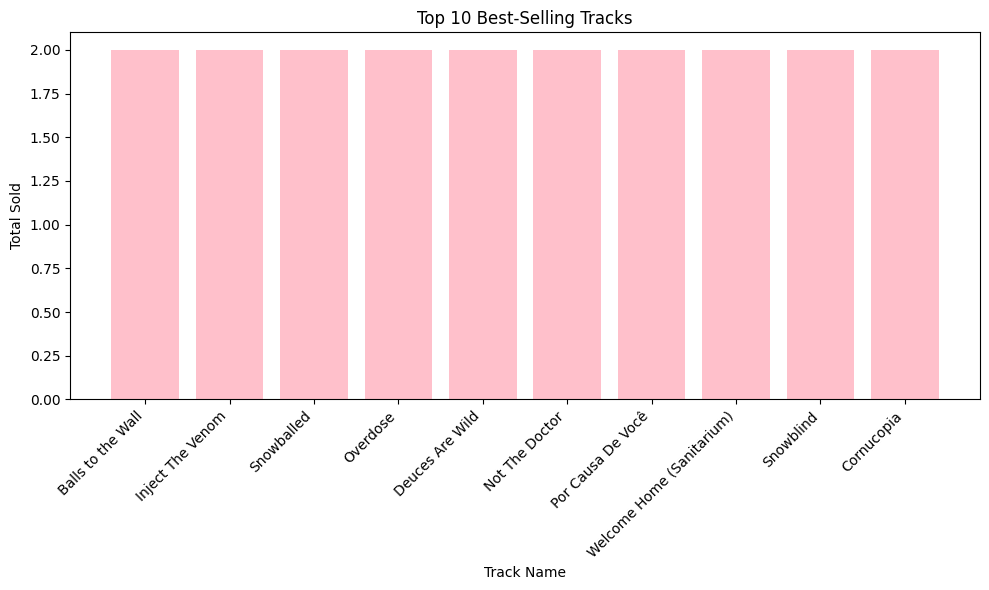

In [ ]:
##สร้างพื้นที่กราฟกว้าง 10 สูง 6
plt.figure(figsize=(10,6))
##สร้าง bar chart x,y
plt.bar(Top_Tracks["Name"],Top_Tracks["TotalSold"],color = "Pink")
##ใส่ชื่อกราฟ
plt.title("Top 10 Best-Selling Tracks")
##ชื่อแกน x
plt.xlabel("Track Name")
##ชื่อแกน y
plt.ylabel("Total Sold")
##หมุนชื่อเพลงให้เอียง 45 องศาเพราะยาวจะได้ไม่ซ้อนกัน
plt.xticks(rotation = 45, ha = "right")
##จัดระยะห่างอัตโนมัติ
plt.tight_layout()
##แสดงกราฟ
plt.show()


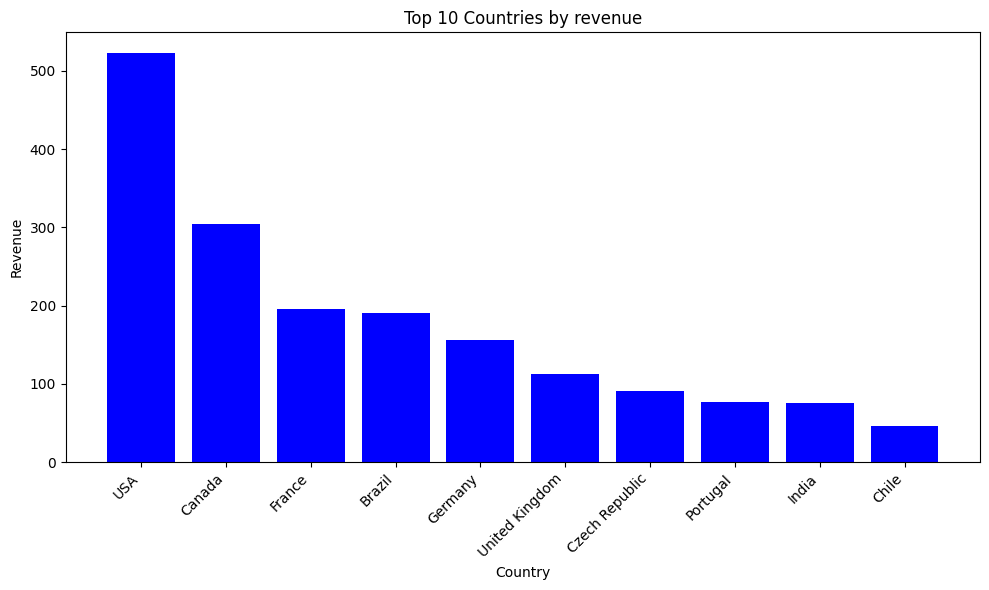

In [66]:
plt.figure(figsize=(10,6))
plt.bar(country_revenue ["BillingCountry"],country_revenue["Revenue"],color = "blue")
plt.title("Top 10 Countries by revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()


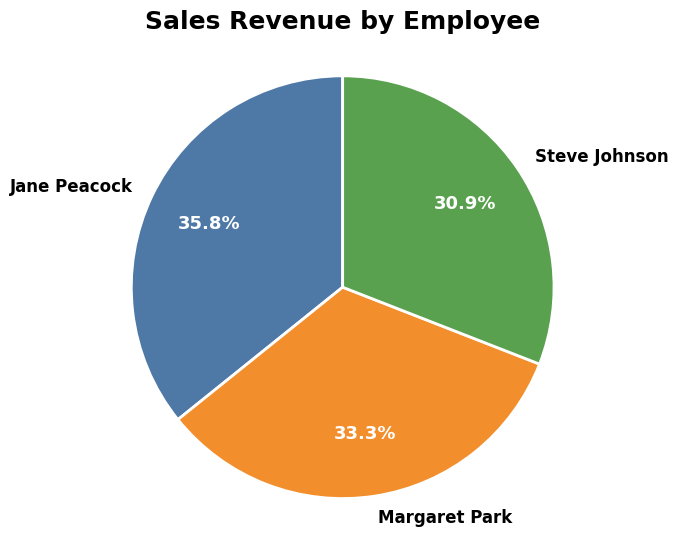

In [77]:
plt.figure(figsize=(6, 6))

colors = ["#4E79A7", "#F28E2B", "#59A14F"]

wedges, texts, autotexts = plt.pie(
    Employee_BestSeller["SumTotal"],
    labels=Employee_BestSeller["EmpName"],
    colors=colors,
    autopct="%.1f%%",
    startangle=90,
    pctdistance=0.7,
    labeldistance=1.1,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    }
)

# ปรับแต่งชื่อพนักงาน
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")

# ปรับแต่งเปอร์เซ็นต์
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

plt.title(
    "Sales Revenue by Employee",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.axis("equal")

plt.show()

## 8. Conclusion

From this analysis of the Chinook database:

- The top-selling tracks each sold two units.
- The USA generated the highest revenue.
- Jane Peacock was the top-performing sales employee.

This project demonstrated how SQL can be integrated with Python, Pandas, and Matplotlib to analyze business data and visualize insights.